# Chapter 2- Data Preprocessing

In [134]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/macro_financial_data.csv",
    index_col=0,
    parse_dates=True
)

df.head()

,mxn_usd,vix,oil_prices,fed_funds_rate,industrial_activity,inflation_rate,banxico_rate
2008-01-01,10.8770,NaN,NaN,3.94,100.9807,3.704372,NaN
2008-01-02,10.8995,23.170000,99.64,NaN,NaN,NaN,NaN
2008-01-03,10.8701,22.490000,99.17,NaN,NaN,NaN,NaN
2008-01-04,10.9240,23.940001,97.90,NaN,NaN,NaN,NaN
2008-01-07,10.8916,23.790001,95.08,NaN,NaN,NaN,NaN


In [135]:
# Check missing values

obs = pd.DataFrame({
    "observations": df.count(),
    "missing_values": df.isna().sum()
})

obs

,observations,missing_values
mxn_usd,4432,1687
vix,4279,1840
oil_prices,4270,1849
fed_funds_rate,205,5914
industrial_activity,205,5914
inflation_rate,199,5920
banxico_rate,6096,23


### 2.1 Imputting Missing data

1. Separate the daily variables and montly variables:

In [136]:
daily_vars = [
    "mxn_usd",
    "vix",
    "oil_prices",
    "banxico_rate"
]

monthly_vars = [
    "inflation_rate",
    "fed_funds_rate",
    "industrial_activity"
]

2. Create montly variables copy to Compare it later:

In [137]:
df_ffill = df.copy()
df_bfill = df.copy()
df_interp = df.copy()

3. Foward Fill for montly variables:

In [138]:
df_ffill[monthly_vars] = (
    df_ffill[monthly_vars]
    .ffill()
)


4. Backward Fill for montly variables: 
    

In [139]:
df_bfill[monthly_vars] = (
    df_bfill[monthly_vars]
    .bfill()
)

5. Interpolation Method for montly variables: 

In [140]:
df_interp[monthly_vars] = (
    df_interp[monthly_vars]
    .interpolate(method="linear")
)

6. Compare the best solution for "inflation_rate" variable: 

In [141]:
compare = pd.DataFrame({
    "original": df["inflation_rate"],
    "ffill": df["inflation_rate"].ffill(),
    "bfill": df["inflation_rate"].bfill(),
    "interpolate": df["inflation_rate"].interpolate()
})

<Axes: title={'center': 'Inflation Filling Methods'}>

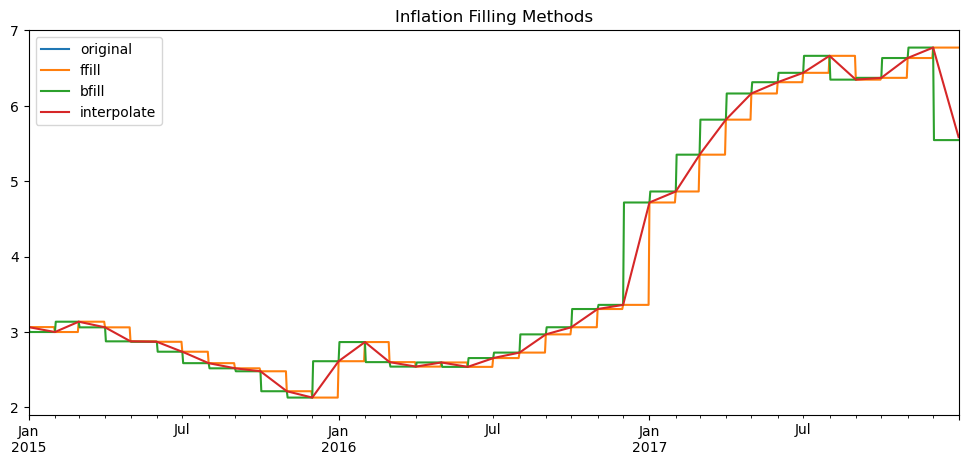

In [142]:
compare["2015":"2017"].plot(
    figsize=(12,5),
    title="Inflation Filling Methods"
)

For the inflation variable, interpolation generates a smooth transition between consecutive observations, whereas the ffill and bfill methods produce stepwise changes. However, inflation is a variable that becomes known only when the official data is released. Therefore, assuming that the market knows intermediate values through interpolation introduces information that was not actually available at that point in time.

7. Compare the best solution for "Fed Funds Rate" variable:

<Axes: title={'center': 'Fed FundsFilling Methods'}>

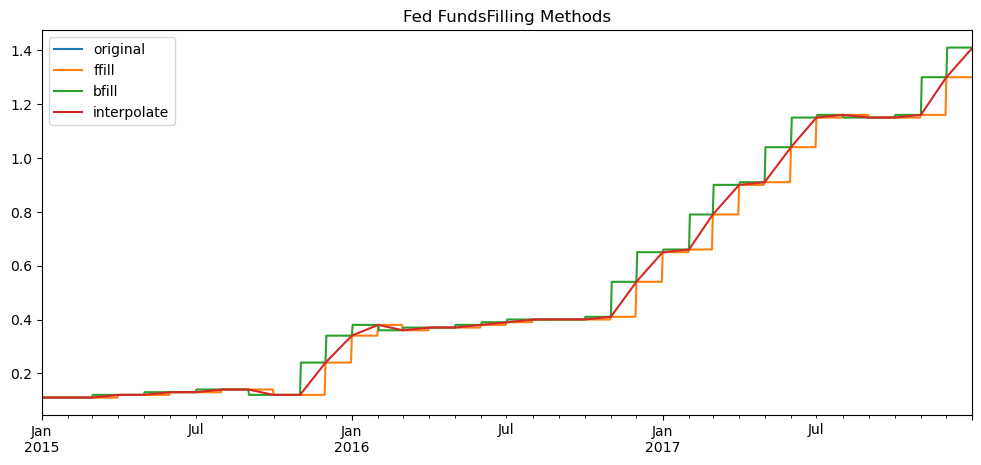

In [143]:
compare = pd.DataFrame({
    "original": df["fed_funds_rate"],
    "ffill": df_ffill["fed_funds_rate"],
    "bfill": df_bfill["fed_funds_rate"],
    "interpolate": df_interp["fed_funds_rate"]
})

compare["2015":"2017"].plot(
    figsize=(12,5),
    title="Fed FundsFilling Methods"
)


The Federal Funds Rate exhibits discrete and infrequent changes. In this case, the ffill method adequately reproduces the actual behavior of the variable, since the rate remains constant until the Federal Reserve announces a new policy decision. Interpolation, on the other hand, creates gradual movements that never occurred in reality.

8. Compare the best solution for "Industrial Activity" variable:

<Axes: title={'center': 'Industrial Activity Filling Methods'}>

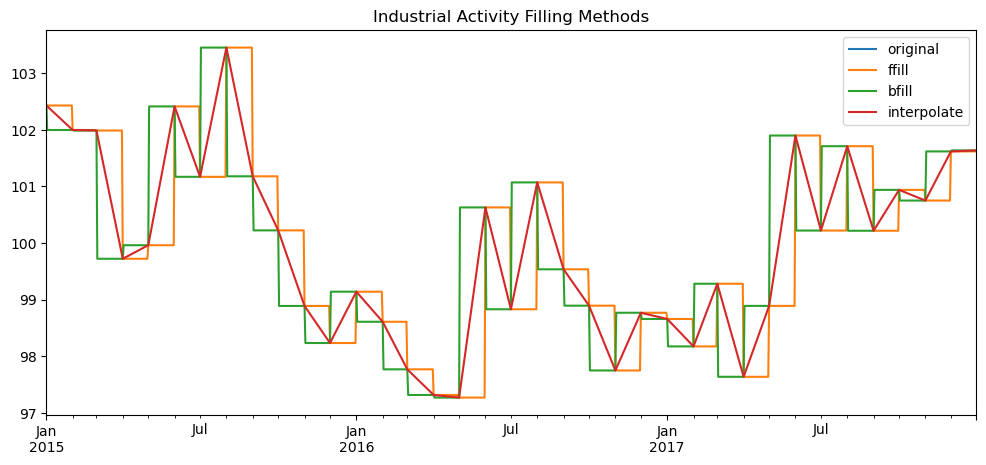

In [144]:
compare = pd.DataFrame({
    "original": df["industrial_activity"],
    "ffill": df_ffill["industrial_activity"],
    "bfill": df_bfill["industrial_activity"],
    "interpolate": df_interp["industrial_activity"]
})

compare["2015":"2017"].plot(
    figsize=(12,5),
    title="Industrial Activity Filling Methods"
)

Industrial activity displays a more volatile dynamic, where interpolation produces a visually smoother series. However, as with inflation, these data are only observable once officially released. Consequently, interpolation once again introduces future information that was not available to economic agents at the time.

In [ ]:
9. Apply FFILL method to montly variables

In [145]:
#Montly variables
monthly_vars = [
    "fed_funds_rate",
    "industrial_activity",
    "inflation_rate"
]

# Aplicar Forward Fill
df[monthly_vars] = df[monthly_vars].ffill()

10. Verify that Montly Variables are daily now

In [146]:
df[monthly_vars].isna().sum()

fed_funds_rate         0
industrial_activity    0
inflation_rate         0
dtype: int64

11. Let's check the remaining missing values again. 

In [147]:
obs = pd.DataFrame({
    "observations": df.count(),
    "missing_values": df.isna().sum()
})

obs

,observations,missing_values
mxn_usd,4432,1687
vix,4279,1840
oil_prices,4270,1849
fed_funds_rate,6119,0
industrial_activity,6119,0
inflation_rate,6119,0
banxico_rate,6096,23


11. Now let's check if missing data is due to holidays or bussiness days in daily variables before drop missing values. 

In [154]:
print("Current shape:")
print(df.shape)

print("\nShape after dropna():")
print(df.dropna().shape)

Current shape:
(4246, 8)

Shape after dropna():
(4245, 8)


It would suggest that the missing values are only weekends and holidays, if we drop it without checking it. Then we  are not gonna know if there is missing data it only compass the bussiness days.

12. Drop remaining missing data. 

In [149]:
df = df.dropna()

In [153]:
df.shape
df.dropna().shape

(4245, 8)

## 2.2 Converting Prices to Returns.

The MXN/USD exchange rate is transformed into logarithmic returns because exchange rate levels are typically non-stationary and exhibit persistent trends over time.From an economic perspective, the MXN/USD exchange rate is highly sensitive to both domestic and international macroeconomic conditions. Changes in U.S. monetary policy, particularly adjustments in the Federal Funds Rate, influence capital flows between emerging markets and the United States. Higher U.S. interest rates often increase the attractiveness of dollar-denominated assets, generating appreciation pressures on the U.S. dollar and depreciation pressures on the Mexican peso.

\[
\begin{array}{cc}
\textbf{Simple Return} & \textbf{Log Return} \\
\\
R_t = \dfrac{P_t - P_{t-1}}{P_{t-1}}
&
r_t = \ln\left(\dfrac{P_t}{P_{t-1}}\right)
\end{array}
\]

1. Convert exchange rate to simple to log

In [161]:
df["usd_mxn_returns"] = np.log(df["mxn_usd"] / df["mxn_usd"].shift(1))

1. Convert VIX to log

In [176]:
df["vix_returns"] = np.log(df["vix"] / df["vix"].shift(1))

Oil prices are transformed into logarithmic returns because commodity price series are generally non-stationary and can experience substantial fluctuations over long periods.Oil prices are particularly relevant for Mexico because the country has historically been an oil-producing and oil-exporting economy. 

Increases in oil prices are often associated with higher export revenues, improved fiscal conditions, and stronger external accounts, factors that may contribute to a stronger Mexican peso. Although the relationship is not always immediate or perfectly linear, oil price movements remain an important macroeconomic factor influencing the Mexican economy and, consequently, the MXN/USD exchange rate.

\[
\begin{array}{cc}
\textbf{Simple Return} & \textbf{Log Return} \\
\\
R_t^{Oil} = \dfrac{P_t^{Oil} - P_{t-1}^{Oil}}{P_{t-1}^{Oil}}
&
r_t^{Oil} = \ln\left(\dfrac{P_t^{Oil}}{P_{t-1}^{Oil}}\right)
\end{array}
\]

2. Let's chech if there is not Log for cero or negative numbers. 

In [120]:
# Check if there are negative observations <= 0
(df["oil_prices"] <= 0).sum()

1

In [126]:
# check min value 
df["oil_prices"].min()

-36.98

In [129]:
# Check problematic date
df[df["oil_prices"] <= 0]

,mxn_usd,vix,oil_prices,fed_funds_rate,industrial_activity,inflation_rate,banxico_rate,mxn_returns,oil_returns
2020-04-20,24.026649,43.830002,-36.98,0.05,82.5429,2.148121,6.5,0.011152,NaN


Note: The negative oil price observed on April 20, 2020 reflects the unprecedented collapse in global oil demand during COVID-19 pandemic and the temporary negative settlement of WTI crude oil futures. This event was globla in nature and not specific to Mexico. 

3. Keep the original dataset but limit log return to only positive values. 

In [156]:
df["oil_returns"] = np.where(
    (df["oil_prices"] > 0) &
    (df["oil_prices"].shift(1) > 0),
    np.log(df["oil_prices"] / df["oil_prices"].shift(1)),
    np.nan
)

/Users/dulcedelapazortiz/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


4.Check finally the Log Returns

In [162]:
df[["usd_mxn_returns", "oil_returns"]].describe()

,usd_mxn_returns,oil_returns
count,4245.000000,4243.000000
mean,0.000150,0.000120
std,0.008510,0.028817
min,-0.068911,-0.281382
25%,-0.004404,-0.012408
50%,-0.000175,0.000828
75%,0.004267,0.012926
max,0.092886,0.425832


## 2.3 Converting currencies 

Note: The dependent variable of this study is the MXN/USD exchange rate, which measures the value of the Mexican peso relative to the U.S. dollar. Therefore, it is kept in its original form to preserve its economic interpretation. The remaining explanatory variables are not directly measured in Mexican pesos, as they represent different economic concepts such as interest rates, inflation, industrial activity, market volatility, and oil price dynamics. In particular, oil prices were transformed into logarithmic returns, making the analysis independent of the original currency denomination. Since returns, rates, and index-based variables are unit-free measures, no additional currency conversion was required. This approach preserves the economic meaning of each variable while ensuring comparability within the econometric framework.

## 2.4 Final Dataset for Analysis 

In [177]:
# Keep only variables used in the project
df_final = df[
    [
    "mxn_usd",
    "oil_prices",
    "usd_mxn_returns",
    "oil_returns",
    "vix",
    "fed_funds_rate",
    "industrial_activity",
    "inflation_rate",
    "banxico_rate", 
    "vix_returns"
]
].copy()

# Final check
print("Shape:", df_final.shape)
print("\nMissing values:")
print(df_final.isna().sum())

# Save clean dataset
df_final.to_csv("mxn_forecasting_clean.csv")

# Preview
df_final.head()

Shape: (4246, 10)

Missing values:
mxn_usd                0
oil_prices             0
usd_mxn_returns        1
oil_returns            3
vix                    0
fed_funds_rate         0
industrial_activity    0
inflation_rate         0
banxico_rate           0
vix_returns            1
dtype: int64


,mxn_usd,oil_prices,usd_mxn_returns,oil_returns,vix,fed_funds_rate,industrial_activity,inflation_rate,banxico_rate,vix_returns
2008-01-22,10.925,89.64,NaN,NaN,31.010000,3.94,100.9807,3.704372,7.5,NaN
2008-01-23,10.893,87.65,-0.002933,-0.022450,29.020000,3.94,100.9807,3.704372,7.5,-0.066324
2008-01-24,10.862,89.98,-0.002850,0.026236,27.780001,3.94,100.9807,3.704372,7.5,-0.043669
2008-01-25,10.866,90.37,0.000368,0.004325,29.080000,3.94,100.9807,3.704372,7.5,0.045734
2008-01-28,10.863,90.99,-0.000276,0.006837,27.780001,3.94,100.9807,3.704372,7.5,-0.045734


In [168]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4246 entries, 2008-01-22 to 2024-12-31
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mxn_usd              4246 non-null   float64
 1   oil_prices           4246 non-null   float64
 2   usd_mxn_returns      4245 non-null   float64
 3   oil_returns          4243 non-null   float64
 4   vix                  4246 non-null   float64
 5   fed_funds_rate       4246 non-null   float64
 6   industrial_activity  4246 non-null   float64
 7   inflation_rate       4246 non-null   float64
 8   banxico_rate         4246 non-null   float64
dtypes: float64(9)
memory usage: 331.7 KB
